# Synthetic Customer Churn Analysis

This notebook loads the synthetic `customers` table from PostgreSQL and performs:

1. **Setup** — import libraries and load database credentials from `.env`.
2. **Data loading** — connect to PostgreSQL with SQLAlchemy and read the table.
3. **Exploratory Data Analysis (EDA)** — summary statistics and matplotlib visualizations.
4. **Modeling** — a Random Forest classifier predicting `target_churn`.


## 1. Setup

In [1]:
# (a) Import libraries and load .env variables
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load environment variables from the local .env file
load_dotenv()

DB_USER = os.getenv("POSTGRES_USER", "postgres")
DB_PASSWORD = os.getenv("POSTGRES_PASSWORD", "postgres")
DB_NAME = os.getenv("POSTGRES_DB", "postgres")
DB_HOST = os.getenv("POSTGRES_HOST", "localhost")
DB_PORT = os.getenv("POSTGRES_PORT", "5432")

print("Environment variables loaded.")

Environment variables loaded.


## 2. Load data from PostgreSQL

In [2]:
# (b) Connect to PostgreSQL and read the 'customers' table
engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

df = pd.read_sql("SELECT * FROM customers", engine)

print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

Loaded 1000 rows and 10 columns


,customer_id,age,income,credit_score,account_balance,tenure_months,num_products,is_active,estimated_salary,target_churn
0,1,46,58517.93,750,65128.18,68,2,1,67450.53,1
1,2,30,41767.83,705,90808.74,37,2,0,44264.03,1
2,3,51,49638.17,807,65932.85,13,3,0,68546.43,1
3,4,53,75847.76,526,144553.27,52,3,1,91477.82,1
4,5,19,60074.83,629,112191.50,32,1,0,50429.01,0


## 3. Exploratory Data Analysis

In [3]:
# Schema, data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       1000 non-null   int64  
 1   age               1000 non-null   int64  
 2   income            1000 non-null   float64
 3   credit_score      1000 non-null   int64  
 4   account_balance   1000 non-null   float64
 5   tenure_months     1000 non-null   int64  
 6   num_products      1000 non-null   int64  
 7   is_active         1000 non-null   int64  
 8   estimated_salary  1000 non-null   float64
 9   target_churn      1000 non-null   int64  
dtypes: float64(3), int64(7)
memory usage: 78.3 KB


In [4]:
# Summary statistics for the numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,1000.0,500.50000,288.819436,1.0,250.7500,500.500,750.2500,1000.00
age,1000.0,41.76900,11.566046,18.0,34.0000,42.000,49.0000,75.00
income,1000.0,58459.36687,24339.479726,15000.0,41743.6450,58905.380,75068.0875,132856.12
credit_score,1000.0,649.66900,77.528847,430.0,595.0000,649.000,702.0000,850.00
account_balance,1000.0,55874.83076,36629.533668,0.0,27547.2700,54268.390,78505.0875,193161.86
tenure_months,1000.0,59.42600,34.456317,1.0,31.0000,58.000,89.0000,120.00
num_products,1000.0,2.52500,1.133428,1.0,1.0000,3.000,4.0000,4.00
is_active,1000.0,0.47300,0.499520,0.0,0.0000,0.000,1.0000,1.00
estimated_salary,1000.0,69608.26266,23636.629221,15000.0,52563.1525,69725.495,85090.0250,152993.23
target_churn,1000.0,0.58700,0.492619,0.0,0.0000,1.000,1.0000,1.00


In [5]:
# Missing values and target class balance
print("Missing values per column:")
print(df.isna().sum())

print("\nTarget distribution (proportion):")
print(df["target_churn"].value_counts(normalize=True).rename("proportion"))

Missing values per column:
customer_id         0
age                 0
income              0
credit_score        0
account_balance     0
tenure_months       0
num_products        0
is_active           0
estimated_salary    0
target_churn        0
dtype: int64

Target distribution (proportion):
target_churn
1    0.587
0    0.413
Name: proportion, dtype: float64


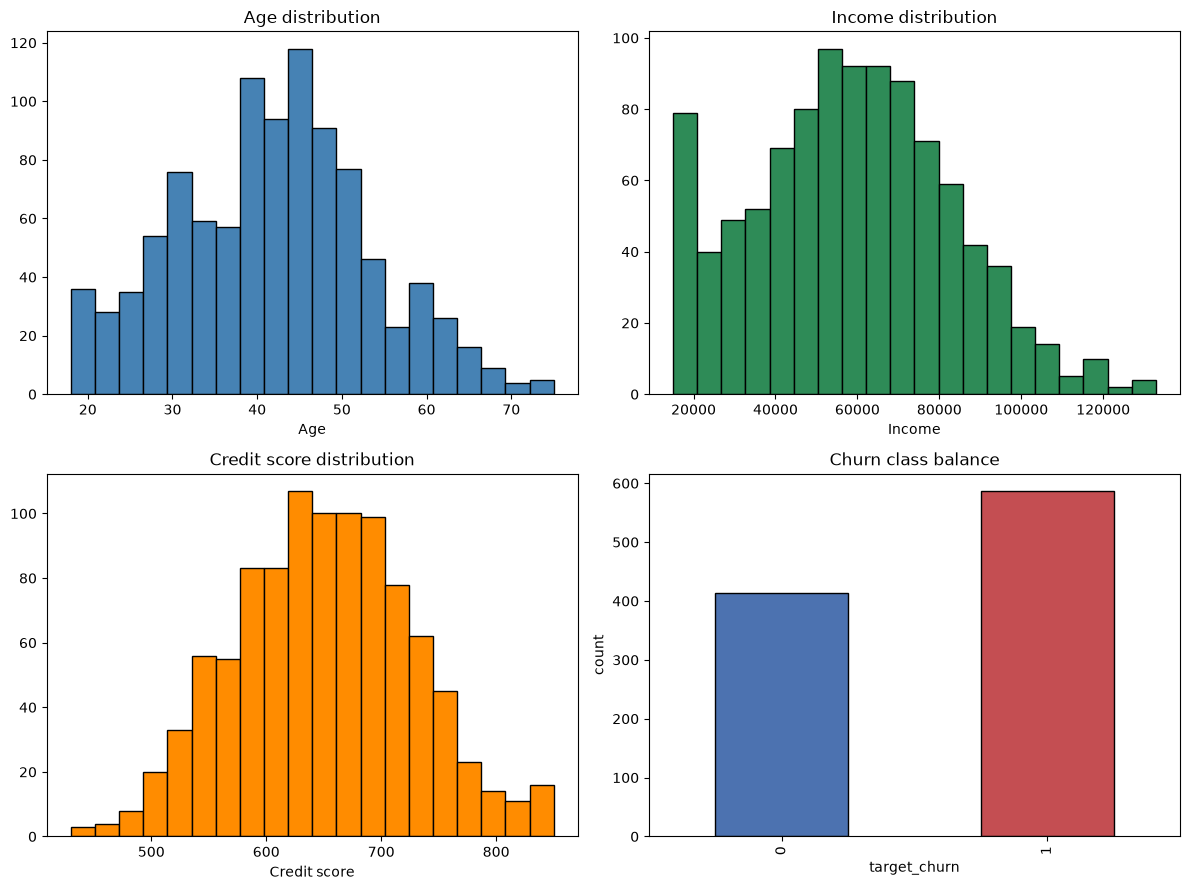

In [6]:
# (c) Basic EDA visualizations with matplotlib
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(df["age"], bins=20, color="steelblue", edgecolor="black")
axes[0, 0].set_title("Age distribution")
axes[0, 0].set_xlabel("Age")

axes[0, 1].hist(df["income"], bins=20, color="seagreen", edgecolor="black")
axes[0, 1].set_title("Income distribution")
axes[0, 1].set_xlabel("Income")

axes[1, 0].hist(df["credit_score"], bins=20, color="darkorange", edgecolor="black")
axes[1, 0].set_title("Credit score distribution")
axes[1, 0].set_xlabel("Credit score")

df["target_churn"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1, 1], color=["#4c72b0", "#c44e52"], edgecolor="black"
)
axes[1, 1].set_title("Churn class balance")
axes[1, 1].set_xlabel("target_churn")
axes[1, 1].set_ylabel("count")

plt.tight_layout()
plt.show()

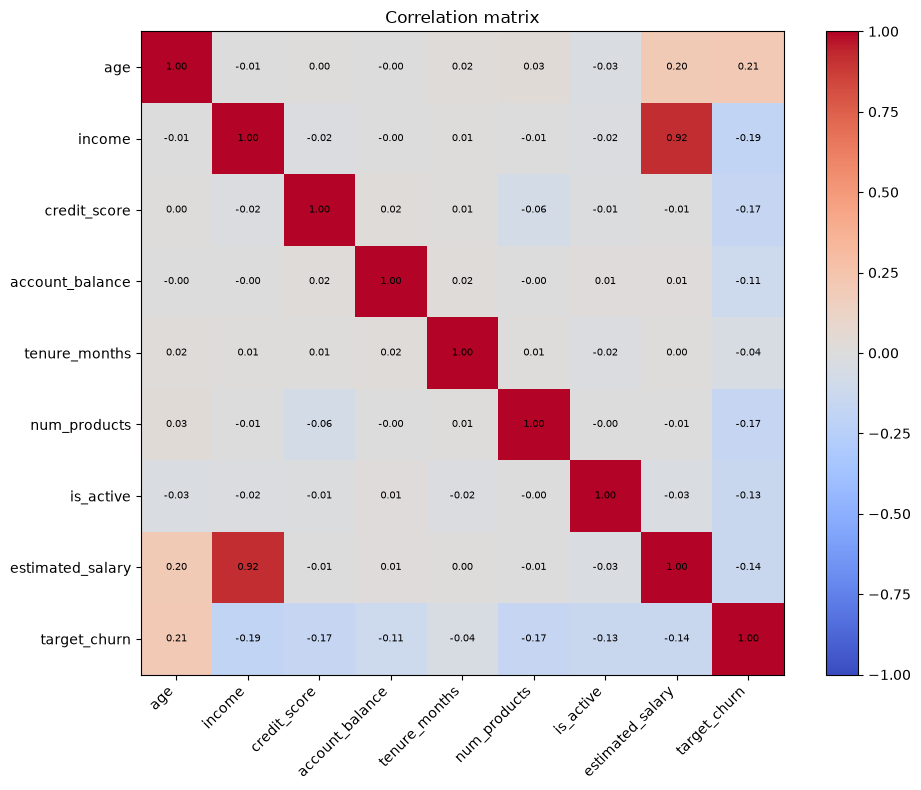

In [7]:
# Correlation heatmap (numeric columns, excluding the identifier)
numeric_df = df.select_dtypes(include=[np.number]).drop(
    columns=["customer_id"], errors="ignore"
)
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

## 4. Machine Learning: Random Forest

In [8]:
# (d) Train a Random Forest classifier to predict target_churn
feature_cols = [c for c in df.columns if c not in ("target_churn", "customer_id")]

X = df[feature_cols]
y = df["target_churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=["no churn", "churn"]))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6650

              precision    recall  f1-score   support

    no churn       0.61      0.55      0.58        83
       churn       0.70      0.74      0.72       117

    accuracy                           0.67       200
   macro avg       0.65      0.65      0.65       200
weighted avg       0.66      0.67      0.66       200

Confusion matrix:
[[46 37]
 [30 87]]


credit_score        0.168775
age                 0.152897
income              0.148123
estimated_salary    0.146464
account_balance     0.144967
tenure_months       0.135233
num_products        0.070406
is_active           0.033135
dtype: float64


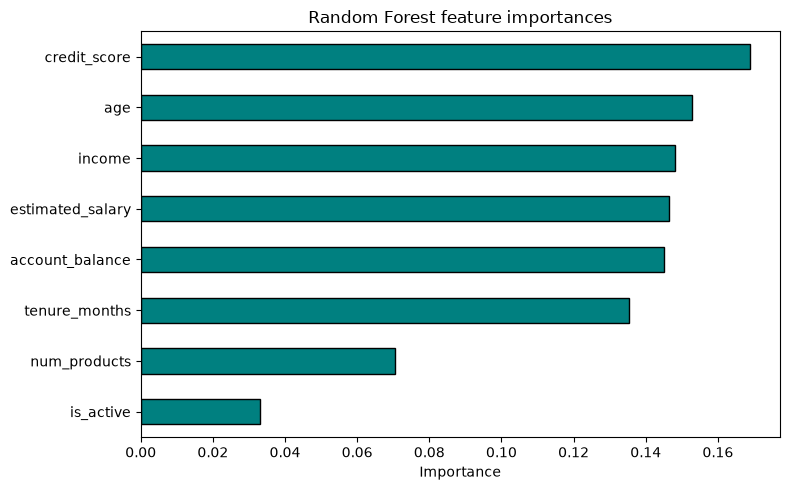

In [9]:
# Feature importances from the fitted Random Forest
importances = (
    pd.Series(model.feature_importances_, index=feature_cols)
    .sort_values(ascending=False)
)
print(importances)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="teal", edgecolor="black")
ax.invert_yaxis()
ax.set_title("Random Forest feature importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()